# End-to-End Data Management Pipeline

We will be conducting an `ELT (Extract - Load - Transform)` process

## Extract

### Load the data frames

In [2]:
import sqlite3
import pandas as pd

# List all tables
conn = sqlite3.connect('customers_demo.db')
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")

tables = cursor.fetchall()
print("Tables in database:", tables)

Tables in database: [('demographics',)]


In [ ]:
conn = sqlite3.connect('customers_demo.db')
df_demo_db = pd.read_sql('SELECT * FROM demographics', conn)
conn.close()

In [57]:
df_demo_db

,Customer_ID,Age,Income,Gender,Education,City
0,1,35,28000.0,Male,High School,Kotte
1,2,59,21000.0,Male,Bachelor,Piliyandala
2,3,56,30000.0,Male,PhD,Piliyandala
3,4,34,47000.0,Female,Master,Thimbirigasyaya
4,5,31,20000.0,Male,High School,Avissawella
...,...,...,...,...,...,...
795,796,33,37000.0,Female,High School,Bambalapitiya
796,797,64,22000.0,Male,High School,Kottawa
797,798,32,31000.0,Female,PhD,Colpetty
798,799,42,22000.0,Male,PhD,Kesbewa


In [4]:
df_location_csv = pd.read_csv('colombo_locations.csv')
df_signup_csv = pd.read_csv('customers_signup.csv')
df_churn_csv = pd.read_csv('churn_data.csv')

Examine the dataframes

In [5]:
df_demo_db.columns

Index(['Customer_ID', 'Age', 'Income', 'Gender', 'Education', 'City'], dtype='object')

In [6]:
df_location_csv.columns

Index(['City', 'Region'], dtype='object')

In [7]:
df_signup_csv.columns

Index(['Customer_ID', 'Signup_Date', 'Signup_Channel'], dtype='object')

In [8]:
df_churn_csv.columns

Index(['Customer_ID', 'Churned'], dtype='object')

Check duplicates

In [9]:
df_dict = {
    'df_demo_db': df_demo_db,
    'df_location_csv': df_location_csv,
    'df_signup_csv': df_signup_csv,
    'df_churn_csv': df_churn_csv
}

for name, df in df_dict.items():
    print(f"{name}: {df.duplicated().sum()} duplicates")


df_demo_db: 0 duplicates
df_location_csv: 0 duplicates
df_signup_csv: 0 duplicates
df_churn_csv: 0 duplicates


In [10]:
for name, df in df_dict.items():
    print(f"{name}:\n {df.describe()}\n")

df_demo_db:
        Customer_ID         Age        Income
count     800.0000  800.000000  8.000000e+02
mean      400.5000   43.581250  3.835500e+04
std       231.0844   14.887846  2.237096e+05
min         1.0000   18.000000  4.000000e+03
25%       200.7500   30.000000  1.575000e+04
50%       400.5000   44.000000  2.200000e+04
75%       600.2500   56.250000  3.000000e+04
max       800.0000   69.000000  4.359000e+06

df_location_csv:
             City Region
count         21     21
unique        21      4
top     Havelock   West
freq           1      6

df_signup_csv:
        Customer_ID
count     800.0000
mean      400.5000
std       231.0844
min         1.0000
25%       200.7500
50%       400.5000
75%       600.2500
max       800.0000

df_churn_csv:
        Customer_ID     Churned
count     800.0000  800.000000
mean      400.5000    0.422500
std       231.0844    0.501805
min         1.0000    0.000000
25%       200.7500    0.000000
50%       400.5000    0.000000
75%       600.2500    

## Load

### Merging dataframes

In [11]:
# Merge Region into Demographics via City
df_merged = df_demo_db.merge(df_location_csv, on='City', how='left') \
                       .merge(df_signup_csv, on='Customer_ID', how='left') \
                       .merge(df_churn_csv, on='Customer_ID', how='left')

df_merged

,Customer_ID,Age,Income,Gender,Education,City,Region,Signup_Date,Signup_Channel,Churned
0,1,35,28000.0,Male,High School,Kotte,East,2023-05-18,Referral,0
1,2,59,21000.0,Male,Bachelor,Piliyandala,South,2023-02-21,Referral,0
2,3,56,30000.0,Male,PhD,Piliyandala,South,2023-01-15,NaN,0
3,4,34,47000.0,Female,Master,Thimbirigasyaya,West,2023-03-25,Referral,1
4,5,31,20000.0,Male,High School,Avissawella,East,2023-05-11,Online,0
...,...,...,...,...,...,...,...,...,...,...
795,796,33,37000.0,Female,High School,Bambalapitiya,West,2023-03-06,Referral,1
796,797,64,22000.0,Male,High School,Kottawa,East,2023-04-09,Offline,0
797,798,32,31000.0,Female,PhD,Colpetty,North,2023-03-13,Offline,1
798,799,42,22000.0,Male,PhD,Kesbewa,South,2023-02-21,Offline,0


In [12]:
# Export merged dataset
df_merged.to_csv('customers_merged.csv', index=False)

#### Read the merged and saved Dataset

In [13]:
df = df_merged
df

,Customer_ID,Age,Income,Gender,Education,City,Region,Signup_Date,Signup_Channel,Churned
0,1,35,28000.0,Male,High School,Kotte,East,2023-05-18,Referral,0
1,2,59,21000.0,Male,Bachelor,Piliyandala,South,2023-02-21,Referral,0
2,3,56,30000.0,Male,PhD,Piliyandala,South,2023-01-15,NaN,0
3,4,34,47000.0,Female,Master,Thimbirigasyaya,West,2023-03-25,Referral,1
4,5,31,20000.0,Male,High School,Avissawella,East,2023-05-11,Online,0
...,...,...,...,...,...,...,...,...,...,...
795,796,33,37000.0,Female,High School,Bambalapitiya,West,2023-03-06,Referral,1
796,797,64,22000.0,Male,High School,Kottawa,East,2023-04-09,Offline,0
797,798,32,31000.0,Female,PhD,Colpetty,North,2023-03-13,Offline,1
798,799,42,22000.0,Male,PhD,Kesbewa,South,2023-02-21,Offline,0


In [14]:
df.set_index('Customer_ID', inplace=True)
df

,Age,Income,Gender,Education,City,Region,Signup_Date,Signup_Channel,Churned
Customer_ID,,,,,,,,,
1,35,28000.0,Male,High School,Kotte,East,2023-05-18,Referral,0
2,59,21000.0,Male,Bachelor,Piliyandala,South,2023-02-21,Referral,0
3,56,30000.0,Male,PhD,Piliyandala,South,2023-01-15,NaN,0
4,34,47000.0,Female,Master,Thimbirigasyaya,West,2023-03-25,Referral,1
5,31,20000.0,Male,High School,Avissawella,East,2023-05-11,Online,0
...,...,...,...,...,...,...,...,...,...
796,33,37000.0,Female,High School,Bambalapitiya,West,2023-03-06,Referral,1
797,64,22000.0,Male,High School,Kottawa,East,2023-04-09,Offline,0
798,32,31000.0,Female,PhD,Colpetty,North,2023-03-13,Offline,1


## Transform

#### Check for invalid values

In [15]:
df['Churned'].value_counts()

Churned
0    465
1    332
2      3
Name: count, dtype: int64

In [16]:
# Drop invalid churn values
df = df.query('Churned == 0 or Churned == 1')
df['Churned'].value_counts()

Churned
0    465
1    332
Name: count, dtype: int64

#### Missing values

In [17]:
df.isna().sum()

Age                0
Income             0
Gender             0
Education          0
City               0
Region             0
Signup_Date        0
Signup_Channel    24
Churned            0
dtype: int64

In [18]:
df['Signup_Channel'].value_counts()

Signup_Channel
Offline     260
Online      257
Referral    256
Name: count, dtype: int64

In [19]:
df[df['Signup_Channel'].isna()]

,Age,Income,Gender,Education,City,Region,Signup_Date,Signup_Channel,Churned
Customer_ID,,,,,,,,,
3,56,30000.0,Male,PhD,Piliyandala,South,2023-01-15,NaN,0
6,48,20000.0,Male,Bachelor,Kotte,East,2023-02-06,NaN,1
24,39,11000.0,Female,Bachelor,Colpetty,North,2023-05-05,NaN,1
29,33,16000.0,Male,Bachelor,Piliyandala,South,2023-03-27,NaN,1
47,46,17000.0,Female,Bachelor,Pamankada,West,2023-03-01,NaN,1
111,22,8000.0,Male,High School,Wellawatthe,West,2023-03-10,NaN,0
196,62,27000.0,Female,Bachelor,Thimbirigasyaya,West,2023-03-24,NaN,1
225,49,17000.0,Male,PhD,Havelock,West,2023-04-21,NaN,1
230,58,31000.0,Male,High School,Colombo,North,2023-05-22,NaN,0


In [20]:
df[['Gender','Signup_Channel','Churned']].value_counts()

Gender  Signup_Channel  Churned
Male    Offline         0          86
Female  Referral        0          84
        Online          0          77
        Offline         0          74
Male    Online          0          70
Female  Online          1          61
Male    Referral        0          61
                        1          57
Female  Offline         1          55
        Referral        1          54
Male    Online          1          49
        Offline         1          45
Name: count, dtype: int64

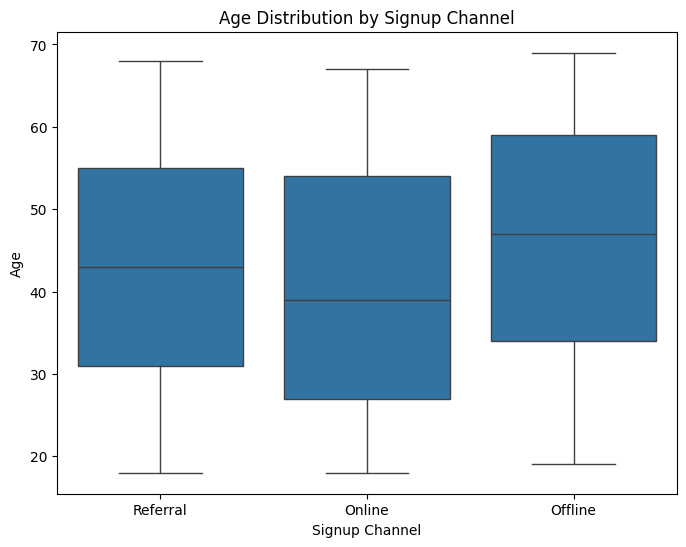

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='Signup_Channel', y='Age')
plt.title('Age Distribution by Signup Channel')
plt.xlabel('Signup Channel')
plt.ylabel('Age')
plt.show()


#### Outliers

In [22]:
df['Age'].describe()

count    797.000000
mean      43.549561
std       14.885041
min       18.000000
25%       30.000000
50%       44.000000
75%       56.000000
max       69.000000
Name: Age, dtype: float64

In [23]:
df['Income'].describe()

count    7.970000e+02
mean     3.840276e+04
std      2.241290e+05
min      4.000000e+03
25%      1.500000e+04
50%      2.200000e+04
75%      3.000000e+04
max      4.359000e+06
Name: Income, dtype: float64

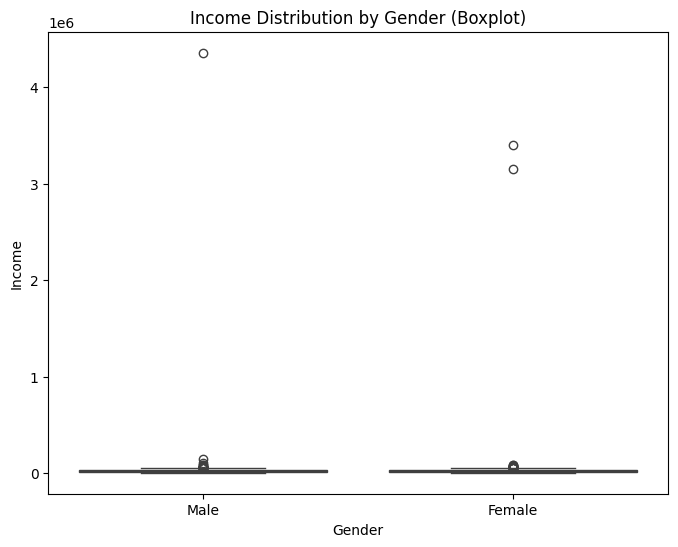

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='Gender', y='Income')
plt.title('Income Distribution by Gender (Boxplot)')
plt.ylabel('Income')
plt.xlabel('Gender')
plt.show()

In [25]:
from scipy import stats
import numpy as np

# Calculate Z-scores for the Income column
z_scores = np.abs(stats.zscore(df['Income'], nan_policy='omit'))  # ignores NaNs

# Define threshold for outliers
threshold = 3

# Find outlier rows
outliers = df[z_scores > threshold]
outliers


,Age,Income,Gender,Education,City,Region,Signup_Date,Signup_Channel,Churned
Customer_ID,,,,,,,,,
539,57,3150000.0,Female,Master,Avissawella,East,2023-03-04,Offline,0
589,46,3406000.0,Female,Master,Malabe,East,2023-03-07,Referral,1
594,18,4359000.0,Male,PhD,Kottawa,East,2023-01-17,Online,1


In [26]:
# --- IQR method ---
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Clip the Income column
df.loc[:, 'Income_unclipped'] = df['Income']
df.loc[:, 'Income'] = df['Income'].clip(lower=lower_bound, upper=upper_bound)

# Check result
df[['Income_unclipped', 'Income']].describe()

C:\Users\NSS\AppData\Local\Temp\ipykernel_19388\1947475465.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'Income_unclipped'] = df['Income']


,Income_unclipped,Income
count,7.970000e+02,797.000000
mean,3.840276e+04,24281.681305
std,2.241290e+05,11472.356581
min,4.000000e+03,4000.000000
25%,1.500000e+04,15000.000000
50%,2.200000e+04,22000.000000
75%,3.000000e+04,30000.000000
max,4.359000e+06,52500.000000


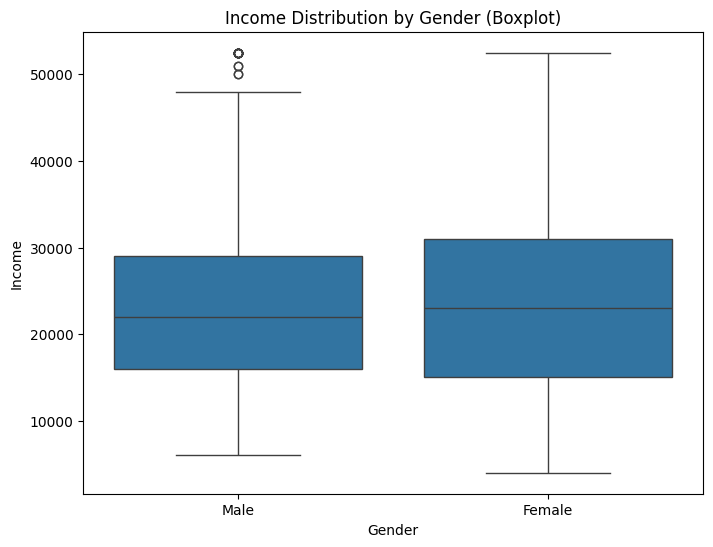

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='Gender', y='Income')
plt.title('Income Distribution by Gender (Boxplot)')
plt.ylabel('Income')
plt.xlabel('Gender')
plt.show()

#### Feature Engineering

In [28]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder, RobustScaler

In [29]:
df_fe = df.copy()

In [30]:
df_fe

,Age,Income,Gender,Education,City,Region,Signup_Date,Signup_Channel,Churned,Income_unclipped
Customer_ID,,,,,,,,,,
1,35,28000.0,Male,High School,Kotte,East,2023-05-18,Referral,0,28000.0
2,59,21000.0,Male,Bachelor,Piliyandala,South,2023-02-21,Referral,0,21000.0
3,56,30000.0,Male,PhD,Piliyandala,South,2023-01-15,NaN,0,30000.0
4,34,47000.0,Female,Master,Thimbirigasyaya,West,2023-03-25,Referral,1,47000.0
5,31,20000.0,Male,High School,Avissawella,East,2023-05-11,Online,0,20000.0
...,...,...,...,...,...,...,...,...,...,...
796,33,37000.0,Female,High School,Bambalapitiya,West,2023-03-06,Referral,1,37000.0
797,64,22000.0,Male,High School,Kottawa,East,2023-04-09,Offline,0,22000.0
798,32,31000.0,Female,PhD,Colpetty,North,2023-03-13,Offline,1,31000.0


Data type transformations

In [31]:
df.dtypes

Age                   int64
Income              float64
Gender               object
Education            object
City                 object
Region               object
Signup_Date          object
Signup_Channel       object
Churned               int64
Income_unclipped    float64
dtype: object

In [32]:
# Age as an integer
df_fe['Age'] = df_fe['Age'].astype(int)

# Income as a float
df_fe['Income'] = df_fe['Income'].astype(float) 

# Gender, education, region and churned as categories
df_fe['Gender'] = df_fe['Gender'].astype('category')
df_fe['Education'] = df_fe['Education'].astype('category')
df_fe['Region'] = df_fe['Region'].astype('category')
df_fe['Churned'] = df_fe['Churned'].astype('category')

# Sign up date as a date time
df_fe['Signup_Date'] = pd.to_datetime(df_fe['Signup_Date'], format = "%Y-%m-%d", errors="coerce")

In [33]:
df_fe.dtypes

Age                          int64
Income                     float64
Gender                    category
Education                 category
City                        object
Region                    category
Signup_Date         datetime64[ns]
Signup_Channel              object
Churned                   category
Income_unclipped           float64
dtype: object

### Numerical Feature Engineering

In [34]:
import numpy as np

# 1. Mathematical Transformation

# log() to reduce skewness in Income
df_fe['Log_Income'] = np.log(df_fe['Income'])

# sqrt() to stabilize variance
df['sqrt_age'] = np.sqrt(df['Age'])

C:\Users\NSS\AppData\Local\Temp\ipykernel_19388\1610026817.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sqrt_age'] = np.sqrt(df['Age'])


In [35]:
# 2. Binning / Discretization
df_fe['Age_Group'] = pd.cut(df_fe['Age'], bins=[0,25,50,100], labels=['Young','Adult','Senior'])

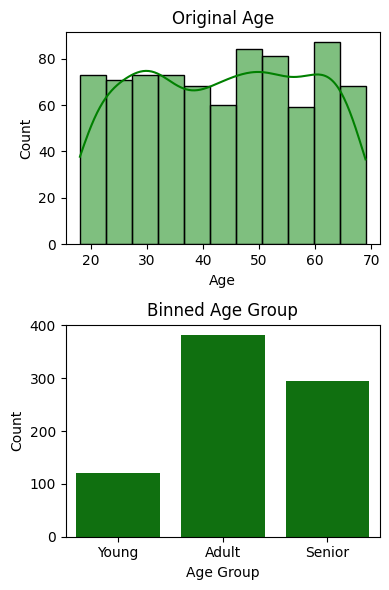

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 1, figsize=(4, 6))

# 1. Original Age
sns.histplot(df_fe['Age'], kde=True, color='green', ax=axes[0])
axes[0].set_title('Original Age', fontsize=12)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

# 2. Binned Age_Group
sns.countplot(x='Age_Group', data=df_fe, color='green', ax=axes[1])
axes[1].set_title('Binned Age Group', fontsize=12)
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [37]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder, RobustScaler

# 3. Normalization / Scaling: scale Age to range [0,1]
scaler = MinMaxScaler()
df_fe['Age_Scaled'] = scaler.fit_transform(df_fe[['Age']])

# 4. Standardization: scale log(Income) to mean=0, std=1
std_scaler = StandardScaler()
df_fe['Log_Income_Std'] = std_scaler.fit_transform(df_fe[['Log_Income']])

# 5. RobustScaler: scale  income using median and IQR
robust_scaler = RobustScaler()
df_fe['Income_Robust'] = robust_scaler.fit_transform(df_fe[['Income']])

In [38]:
df_fe[['Income', 'Log_Income', 'Log_Income_Std', 'Income_Robust']].head()

,Income,Log_Income,Log_Income_Std,Income_Robust
Customer_ID,,,,
1,28000.0,10.239960,0.531729,0.400000
2,21000.0,9.952278,-0.075843,-0.066667
3,30000.0,10.308953,0.677439,0.533333
4,47000.0,10.757903,1.625602,1.666667
5,20000.0,9.903488,-0.178886,-0.133333


Visualization

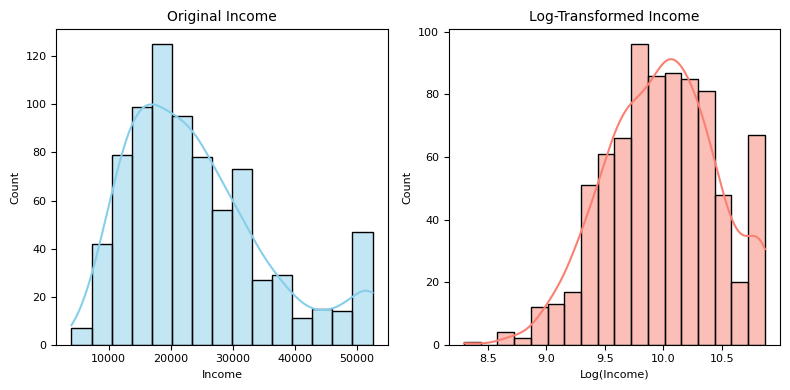

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Income --> Log_Income
sns.histplot(df_fe['Income'], kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Original Income', fontsize=10)
axes[0].set_xlabel('Income', fontsize=8)
axes[0].set_ylabel('Count', fontsize=8)
axes[0].tick_params(axis='both', labelsize=8)

sns.histplot(df_fe['Log_Income'], kde=True, color='salmon', ax=axes[1])
axes[1].set_title('Log-Transformed Income', fontsize=10)
axes[1].set_xlabel('Log(Income)', fontsize=8)
axes[1].set_ylabel('Count', fontsize=8)
axes[1].tick_params(axis='both', labelsize=8)

plt.tight_layout()
plt.show()

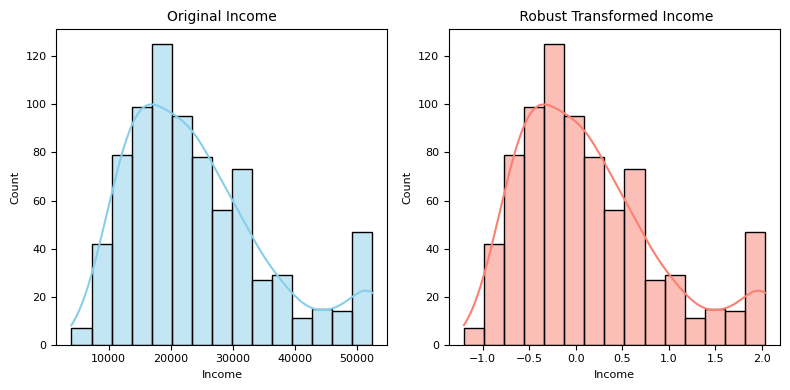

In [40]:

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Income --> Log_Income
sns.histplot(df_fe['Income'], kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Original Income', fontsize=10)
axes[0].set_xlabel('Income', fontsize=8)
axes[0].set_ylabel('Count', fontsize=8)
axes[0].tick_params(axis='both', labelsize=8)

sns.histplot(df_fe['Income_Robust'], kde=True, color='salmon', ax=axes[1])
axes[1].set_title(' Robust Transformed Income', fontsize=10)
axes[1].set_xlabel('Income', fontsize=8)
axes[1].set_ylabel('Count', fontsize=8)
axes[1].tick_params(axis='both', labelsize=8)

plt.tight_layout()
plt.show()


### Categorical Feature Engineering

In [41]:
# 1. Label Encoding: convert Gender categories into integers
le = LabelEncoder()
df_fe['Gender_Label'] = le.fit_transform(df_fe['Gender'])

# 2. Ordinal Encoding: encode Education with meaningful order
education_order = {'High School':0, 'Bachelor':1, 'Master':2, 'PhD':3}
df_fe['Education_Ord'] = df_fe['Education'].map(education_order)

# 3. One-Hot Encoding: create binary columns for each Region
df_fe = pd.get_dummies(df_fe, columns=['Region'], prefix='Region')

# 4. Dummy Encoding: create binary columns with one less than total
df_fe_dummy = pd.get_dummies(df, columns=['Region'], prefix='Region', drop_first=True)

# 5. Target Encoding: replace Region with average churn rate
target_mean = df.groupby('Region')['Churned'].mean().to_dict()
df_fe['Region_TargetEnc'] = df['Region'].map(target_mean)

### Date-Time Feature Engineering

In [42]:
# 1. Extract year component
df_fe['Signup_Year'] = df_fe['Signup_Date'].dt.year  

# 2. Extract month component
df_fe['Signup_Month'] = df_fe['Signup_Date'].dt.month  

# 3. Extract day component
df_fe['Signup_Day'] = df_fe['Signup_Date'].dt.day  

# 4. Extract weekday component
df_fe['Signup_Weekday'] = df_fe['Signup_Date'].dt.weekday  
df_fe['Weekday_Name'] = df_fe['Signup_Date'].dt.day_name()  # for reference

# 5. Boolean feature: whether signup was on weekend
df_fe['Is_Weekend'] = df_fe['Signup_Date'].dt.weekday >=5 

# 6. Time difference feature: days since signup
df_fe['Days_Since_Signup'] = (pd.to_datetime('2023-06-01') - df_fe['Signup_Date']).dt.days  

In [43]:
df_fe.head()

,Age,Income,Gender,Education,City,Signup_Date,Signup_Channel,Churned,Income_unclipped,Log_Income,...,Region_South,Region_West,Region_TargetEnc,Signup_Year,Signup_Month,Signup_Day,Signup_Weekday,Weekday_Name,Is_Weekend,Days_Since_Signup
Customer_ID,,,,,,,,,,,,,,,,,,,,,
1,35,28000.0,Male,High School,Kotte,2023-05-18,Referral,0,28000.0,10.239960,...,False,False,0.402985,2023,5,18,3,Thursday,False,14
2,59,21000.0,Male,Bachelor,Piliyandala,2023-02-21,Referral,0,21000.0,9.952278,...,True,False,0.377143,2023,2,21,1,Tuesday,False,100
3,56,30000.0,Male,PhD,Piliyandala,2023-01-15,NaN,0,30000.0,10.308953,...,True,False,0.377143,2023,1,15,6,Sunday,True,137
4,34,47000.0,Female,Master,Thimbirigasyaya,2023-03-25,Referral,1,47000.0,10.757903,...,False,True,0.393665,2023,3,25,5,Saturday,True,68
5,31,20000.0,Male,High School,Avissawella,2023-05-11,Online,0,20000.0,9.903488,...,False,False,0.402985,2023,5,11,3,Thursday,False,21


In [44]:
df_fe.columns

Index(['Age', 'Income', 'Gender', 'Education', 'City', 'Signup_Date',
       'Signup_Channel', 'Churned', 'Income_unclipped', 'Log_Income',
       'Age_Group', 'Age_Scaled', 'Log_Income_Std', 'Income_Robust',
       'Gender_Label', 'Education_Ord', 'Region_East', 'Region_North',
       'Region_South', 'Region_West', 'Region_TargetEnc', 'Signup_Year',
       'Signup_Month', 'Signup_Day', 'Signup_Weekday', 'Weekday_Name',
       'Is_Weekend', 'Days_Since_Signup'],
      dtype='object')

In [45]:
df_fe = df_fe[['Age', 'Age_Group', 'Gender', 'Gender_Label', 
       'Income', 'Log_Income',
       'Education', 'Education_Ord', 
       'Region_East', 'Region_North', 'Region_South', 'Region_West',
       'Signup_Year', 'Signup_Month', 'Signup_Day', 'Signup_Weekday', 'Days_Since_Signup',
       'Signup_Channel', 
       'Churned']]
df_fe

,Age,Age_Group,Gender,Gender_Label,Income,Log_Income,Education,Education_Ord,Region_East,Region_North,Region_South,Region_West,Signup_Year,Signup_Month,Signup_Day,Signup_Weekday,Days_Since_Signup,Signup_Channel,Churned
Customer_ID,,,,,,,,,,,,,,,,,,,
1,35,Adult,Male,1,28000.0,10.239960,High School,0,True,False,False,False,2023,5,18,3,14,Referral,0
2,59,Senior,Male,1,21000.0,9.952278,Bachelor,1,False,False,True,False,2023,2,21,1,100,Referral,0
3,56,Senior,Male,1,30000.0,10.308953,PhD,3,False,False,True,False,2023,1,15,6,137,NaN,0
4,34,Adult,Female,0,47000.0,10.757903,Master,2,False,False,False,True,2023,3,25,5,68,Referral,1
5,31,Adult,Male,1,20000.0,9.903488,High School,0,True,False,False,False,2023,5,11,3,21,Online,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
796,33,Adult,Female,0,37000.0,10.518673,High School,0,False,False,False,True,2023,3,6,0,87,Referral,1
797,64,Senior,Male,1,22000.0,9.998798,High School,0,True,False,False,False,2023,4,9,6,53,Offline,0
798,32,Adult,Female,0,31000.0,10.341742,PhD,3,False,True,False,False,2023,3,13,0,80,Offline,1


### Imputation of Signup Channel based on Age brackets

In [46]:
df = df_fe

In [47]:
df.columns

Index(['Age', 'Age_Group', 'Gender', 'Gender_Label', 'Income', 'Log_Income',
       'Education', 'Education_Ord', 'Region_East', 'Region_North',
       'Region_South', 'Region_West', 'Signup_Year', 'Signup_Month',
       'Signup_Day', 'Signup_Weekday', 'Days_Since_Signup', 'Signup_Channel',
       'Churned'],
      dtype='object')

In [48]:
df[['Age_Group', 'Signup_Channel']].value_counts()

Age_Group  Signup_Channel
Adult      Offline           126
           Referral          122
           Online            120
Senior     Offline           113
           Referral           94
           Online             80
Young      Online             57
           Referral           40
           Offline            21
Name: count, dtype: int64

In [49]:
# Impute Signup_Channel for missing values based on Age_Group
df.loc[df['Signup_Channel'].isna() & df['Age_Group'].isin(['Adult','Senior']), 'Signup_Channel'] = 'Offline'
df.loc[df['Signup_Channel'].isna() & df['Age_Group'].isin(['Young']), 'Signup_Channel'] = 'Online'

# Check
df['Signup_Channel'].value_counts(dropna=False)

Signup_Channel
Offline     282
Online      259
Referral    256
Name: count, dtype: int64

In [50]:
df.isna().sum()

Age                  0
Age_Group            0
Gender               0
Gender_Label         0
Income               0
Log_Income           0
Education            0
Education_Ord        0
Region_East          0
Region_North         0
Region_South         0
Region_West          0
Signup_Year          0
Signup_Month         0
Signup_Day           0
Signup_Weekday       0
Days_Since_Signup    0
Signup_Channel       0
Churned              0
dtype: int64

In [51]:
df.head(15)

,Age,Age_Group,Gender,Gender_Label,Income,Log_Income,Education,Education_Ord,Region_East,Region_North,Region_South,Region_West,Signup_Year,Signup_Month,Signup_Day,Signup_Weekday,Days_Since_Signup,Signup_Channel,Churned
Customer_ID,,,,,,,,,,,,,,,,,,,
1,35,Adult,Male,1,28000.0,10.239960,High School,0,True,False,False,False,2023,5,18,3,14,Referral,0
2,59,Senior,Male,1,21000.0,9.952278,Bachelor,1,False,False,True,False,2023,2,21,1,100,Referral,0
3,56,Senior,Male,1,30000.0,10.308953,PhD,3,False,False,True,False,2023,1,15,6,137,Offline,0
4,34,Adult,Female,0,47000.0,10.757903,Master,2,False,False,False,True,2023,3,25,5,68,Referral,1
5,31,Adult,Male,1,20000.0,9.903488,High School,0,True,False,False,False,2023,5,11,3,21,Online,0
6,48,Adult,Male,1,20000.0,9.903488,Bachelor,1,True,False,False,False,2023,2,6,0,115,Offline,1
7,41,Adult,Female,0,49000.0,10.799576,Bachelor,1,False,False,False,True,2023,5,6,5,26,Offline,1
8,52,Senior,Male,1,32000.0,10.373491,Bachelor,1,False,True,False,False,2023,2,9,3,112,Offline,0
9,61,Senior,Female,0,17000.0,9.740969,PhD,3,True,False,False,False,2023,3,13,0,80,Offline,0


### Examine the final dataframe

In [52]:
group_income = df.groupby(['Age_Group', 'Gender','Education','Signup_Channel', 'Churned'], observed=True)['Income'].mean().reset_index()
group_income.sort_values(by=['Churned','Income'], ascending=False)

,Age_Group,Gender,Education,Signup_Channel,Churned,Income
11,Young,Female,Master,Offline,1,52500.000000
124,Senior,Male,Master,Offline,1,38125.000000
46,Adult,Female,High School,Offline,1,35812.500000
56,Adult,Female,Master,Referral,1,34142.857143
36,Young,Male,PhD,Online,1,32300.000000
...,...,...,...,...,...,...
125,Senior,Male,Master,Online,0,16428.571429
133,Senior,Male,PhD,Referral,0,14750.000000
33,Young,Male,PhD,Offline,0,13500.000000
37,Young,Male,PhD,Referral,0,13000.000000


# Complete pipeline

In [53]:
import sqlite3
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, LabelEncoder

class CustomerDataPipeline:
    def __init__(self, db_file, location_csv, signup_csv, churn_csv):
        self.db_file = db_file
        self.location_csv = location_csv
        self.signup_csv = signup_csv
        self.churn_csv = churn_csv
        self.df = None
        self.df_fe = None

    def load_data(self):
        # Read from SQLite and CSVs
        conn = sqlite3.connect(self.db_file)
        df_demo = pd.read_sql('SELECT * FROM demographics', conn)
        conn.close()

        df_location = pd.read_csv(self.location_csv)
        df_signup = pd.read_csv(self.signup_csv)
        df_churn = pd.read_csv(self.churn_csv)

        # Merge all datasets
        self.df = (df_demo.merge(df_location, on='City', how='left')
                          .merge(df_signup, on='Customer_ID', how='left')
                          .merge(df_churn, on='Customer_ID', how='left'))

        # Set Customer_ID as index
        self.df.set_index('Customer_ID', inplace=True)
        return self

    def clean_data(self):
        # Drop invalid churn values
        self.df = self.df.query('Churned == 0 or Churned == 1')

        # Clip Income using IQR
        Q1 = self.df['Income'].quantile(0.25)
        Q3 = self.df['Income'].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        self.df['Income_unclipped'] = self.df['Income']
        self.df['Income'] = np.clip(self.df['Income'].values, lower, upper)

        return self

    def feature_engineering(self):
        df = self.df.copy()
        
        # Numerical transformations
        df['Log_Income'] = np.log(df['Income'])
        df['sqrt_age'] = np.sqrt(df['Age'])

        # Binning / discretization
        df['Age_Group'] = pd.cut(df['Age'], bins=[0,25,50,100], labels=['Young','Adult','Senior'])

        # Scaling
        df['Age_Scaled'] = MinMaxScaler().fit_transform(df[['Age']])
        df['Log_Income_Std'] = StandardScaler().fit_transform(df[['Log_Income']])
        df['Income_Robust'] = RobustScaler().fit_transform(df[['Income']])

        # Encoding
        df['Gender_Label'] = LabelEncoder().fit_transform(df['Gender'])
        edu_order = {'High School':0, 'Bachelor':1, 'Master':2, 'PhD':3}
        df['Education_Ord'] = df['Education'].map(edu_order)
        df = pd.get_dummies(df, columns=['Region'], prefix='Region')

        # Signup date features
        df['Signup_Date'] = pd.to_datetime(df['Signup_Date'], errors='coerce')
        df['Signup_Year'] = df['Signup_Date'].dt.year
        df['Signup_Month'] = df['Signup_Date'].dt.month
        df['Signup_Day'] = df['Signup_Date'].dt.day
        df['Signup_Weekday'] = df['Signup_Date'].dt.weekday
        df['Days_Since_Signup'] = (pd.to_datetime('2023-06-01') - df['Signup_Date']).dt.days

        # Impute Signup_Channel based on Age_Group
        df.loc[df['Signup_Channel'].isna() & df['Age_Group'].isin(['Adult','Senior']), 'Signup_Channel'] = 'Offline'
        df.loc[df['Signup_Channel'].isna() & df['Age_Group'].isin(['Young']), 'Signup_Channel'] = 'Online'

        # Keep relevant columns
        self.df_fe = df[['Age', 'Age_Group', 'Gender', 'Gender_Label', 
                         'Income', 'Log_Income',
                         'Education', 'Education_Ord', 
                         'Region_East', 'Region_North', 'Region_South', 'Region_West',
                         'Signup_Year', 'Signup_Month', 'Signup_Day', 'Signup_Weekday', 'Days_Since_Signup',
                         'Signup_Channel', 
                         'Churned']]
        return self

    def run_full_pipeline(self):
        return (self.load_data()
                    .clean_data()
                    .feature_engineering()
                    .df_fe)

Execute the pipeline

In [54]:
if __name__ == "__main__":
    pipeline = CustomerDataPipeline(
        db_file='customers_demo.db',
        location_csv='colombo_locations.csv',
        signup_csv='customers_signup.csv',
        churn_csv='churn_data.csv'
    )
    
    cleaned_data = pipeline.run_full_pipeline()

In [55]:
cleaned_data

,Age,Age_Group,Gender,Gender_Label,Income,Log_Income,Education,Education_Ord,Region_East,Region_North,Region_South,Region_West,Signup_Year,Signup_Month,Signup_Day,Signup_Weekday,Days_Since_Signup,Signup_Channel,Churned
Customer_ID,,,,,,,,,,,,,,,,,,,
1,35,Adult,Male,1,28000.0,10.239960,High School,0,True,False,False,False,2023,5,18,3,14,Referral,0
2,59,Senior,Male,1,21000.0,9.952278,Bachelor,1,False,False,True,False,2023,2,21,1,100,Referral,0
3,56,Senior,Male,1,30000.0,10.308953,PhD,3,False,False,True,False,2023,1,15,6,137,Offline,0
4,34,Adult,Female,0,47000.0,10.757903,Master,2,False,False,False,True,2023,3,25,5,68,Referral,1
5,31,Adult,Male,1,20000.0,9.903488,High School,0,True,False,False,False,2023,5,11,3,21,Online,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
796,33,Adult,Female,0,37000.0,10.518673,High School,0,False,False,False,True,2023,3,6,0,87,Referral,1
797,64,Senior,Male,1,22000.0,9.998798,High School,0,True,False,False,False,2023,4,9,6,53,Offline,0
798,32,Adult,Female,0,31000.0,10.341742,PhD,3,False,True,False,False,2023,3,13,0,80,Offline,1


Export data

In [56]:
cleaned_data.to_csv("churn_data_final_output.csv", index=False)